# 🔗 Actividad 06 — Integración Multimodal
Merge Provincia/Mes: MIDAGRI + INDECI + Noticias

In [1]:
%matplotlib inline
import os, sys, json, re, warnings, unicodedata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; REPORTS=DIRS['reports']; PROCESSED=DIRS['processed']
print(f"✅ Setup OK | {os.getcwd()}")

✅ Setup OK | C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


In [2]:

df_m=pd.read_csv(f"{INTERIM}/midagri_limon_clean.csv")
df_ev=pd.read_csv(f"{INTERIM}/indeci_eventos_clean.csv",low_memory=False)
df_n=pd.read_csv(f"{INTERIM}/agraria_noticias_clean.csv")
print(f"MIDAGRI: {len(df_m):,} | INDECI: {len(df_ev):,} | Noticias: {len(df_n):,}")


MIDAGRI: 19,573 | INDECI: 13,487 | Noticias: 528


## 6.1 Agregación MIDAGRI — Mensual × Provincia

In [3]:

midagri_agg=(df_m.groupby(['fecha_evento','departamento','provincia'])
    .agg(produccion_t=('produccion_t','sum'),cosecha_ha=('cosecha_ha','sum'),
         precio_chacra_kg=('precio_chacra_kg','mean')).reset_index())
print(f"MIDAGRI agregado: {len(midagri_agg):,} filas")
display(midagri_agg.head(4))


MIDAGRI agregado: 4,530 filas


,fecha_evento,departamento,provincia,produccion_t,cosecha_ha,precio_chacra_kg
0,2021-01,AMAZONAS,BAGUA,25.70,0.0,1.960000
1,2021-01,AMAZONAS,CHACHAPOYAS,23.16,0.0,1.500000
2,2021-01,AMAZONAS,LUYA,29.98,0.0,1.339167
3,2021-01,AMAZONAS,UTCUBAMBA,429.80,0.0,0.991667


## 6.2 Agregación INDECI

In [4]:

pa='personas_afectadas' if 'personas_afectadas' in df_ev.columns else 'fenomeno'
hc='has_cultivo_perdidas' if 'has_cultivo_perdidas' in df_ev.columns else 'fenomeno'
indeci_agg=(df_ev.dropna(subset=['fecha_evento','departamento','provincia'])
    .groupby(['fecha_evento','departamento','provincia'])
    .agg(num_emergencias=('fenomeno','count'),total_afectados=(pa,'sum'),
         has_cultivo_perdidas=(hc,'sum')).reset_index())
print(f"INDECI agregado: {len(indeci_agg):,} filas")
display(indeci_agg.head(4))


INDECI agregado: 1,183 filas


,fecha_evento,departamento,provincia,num_emergencias,total_afectados,has_cultivo_perdidas
0,2021-01,AMAZONAS,BAGUA,2,0.0,0.00
1,2021-01,AMAZONAS,BONGARA,1,36.0,3.28
2,2021-01,AMAZONAS,CHACHAPOYAS,1,2.0,3.00
3,2021-01,AMAZONAS,LUYA,1,0.0,0.00


## 6.3 Esqueleto Temporal + Left Joins

In [5]:

df_n['fecha_evento']=pd.to_datetime(df_n['fecha'],errors='coerce').dt.strftime('%Y-%m')
noticias_agg=df_n.groupby('fecha_evento').agg(n_noticias=('titular','count')).reset_index()
ANHO_I,ANHO_F=CFG['ANHO_INICIO'],CFG['ANHO_FIN']
fechas=pd.date_range(f'{ANHO_I}-01-01',f'{ANHO_F}-08-01',freq='MS')
provincias=midagri_agg[['departamento','provincia']].drop_duplicates()
skeleton=pd.DataFrame([(d.strftime('%Y-%m'),r['departamento'],r['provincia'])
    for d in fechas for _,r in provincias.iterrows()],
    columns=['fecha_evento','departamento','provincia'])
print(f"Esqueleto: {len(skeleton):,} ({len(fechas)} meses × {len(provincias)} provincias)")
df_int=skeleton.merge(midagri_agg,on=['fecha_evento','departamento','provincia'],how='left')
df_int=df_int.merge(indeci_agg,on=['fecha_evento','departamento','provincia'],how='left')
df_int=df_int.merge(noticias_agg,on='fecha_evento',how='left')
df_int['produccion_t']=df_int['produccion_t'].fillna(0)
df_int['num_emergencias']=df_int['num_emergencias'].fillna(0)
df_int['n_noticias']=df_int['n_noticias'].fillna(0)
df_int=df_int.sort_values(['departamento','provincia','fecha_evento'])
df_int['precio_chacra_kg']=df_int.groupby(['departamento','provincia'])['precio_chacra_kg'].ffill().bfill()
print(f"Dataset integrado: {len(df_int):,} filas | Duplicados: {df_int.duplicated(['fecha_evento','departamento','provincia']).sum()}")


Esqueleto: 5,880 (56 meses × 105 provincias)
Dataset integrado: 5,880 filas | Duplicados: 0


## 6.4 Visualización de Cobertura

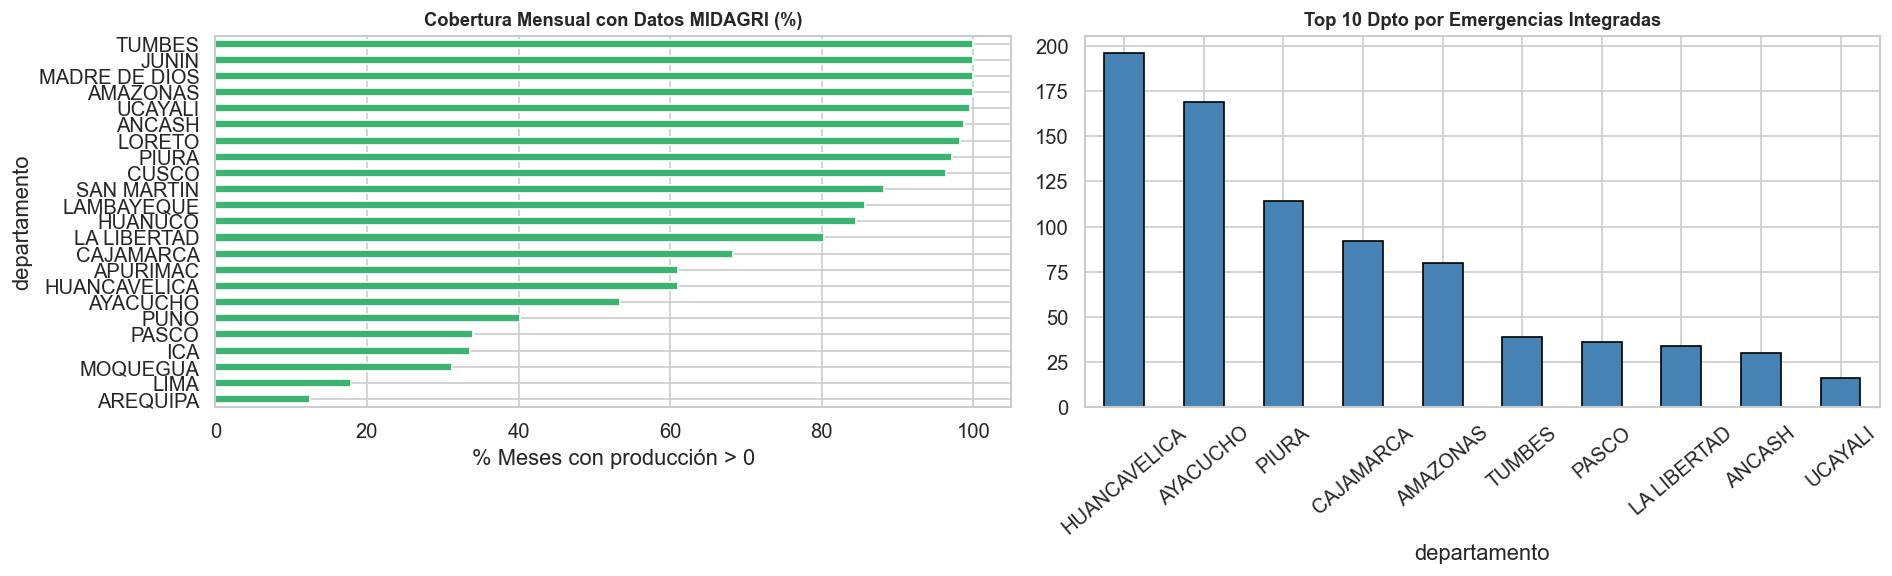

[OK] data\02_interim/dataset_integrado.csv
✅ [ACTIVIDAD 06] COMPLETADA


In [6]:

fig,axes=plt.subplots(1,2,figsize=(16,5))
cob=df_int.groupby('departamento').apply(lambda x:(x['produccion_t']>0).mean()*100).sort_values()
cob.plot(kind='barh',ax=axes[0],color='mediumseagreen',edgecolor='white')
axes[0].set_title('Cobertura Mensual con Datos MIDAGRI (%)',fontsize=11,fontweight='bold')
axes[0].set_xlabel('% Meses con producción > 0')
em=df_int.groupby('departamento')['num_emergencias'].sum().sort_values(ascending=False).head(10)
em.plot(kind='bar',ax=axes[1],color='steelblue',edgecolor='black')
axes[1].set_title('Top 10 Dpto por Emergencias Integradas',fontsize=11,fontweight='bold')
axes[1].tick_params(axis='x',rotation=40)
plt.tight_layout(); plt.show()
out=f"{INTERIM}/dataset_integrado.csv"; df_int.to_csv(out,index=False,encoding='utf-8-sig')
print(f"[OK] {out}")
print("✅ [ACTIVIDAD 06] COMPLETADA")


## TODO: INTEGRACIÓN DATA NASA (COMPAÑERO)
```python
df_nasa=pd.read_csv(f"{INTERIM}/nasa_clima_raw.csv")
df_nasa['fecha_evento']=pd.to_datetime(df_nasa['DATE']).dt.strftime('%Y-%m')
nasa_agg=df_nasa.groupby(['fecha_evento','departamento','provincia'])[
    ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M']].mean().reset_index()
df_int=df_int.merge(nasa_agg,on=['fecha_evento','departamento','provincia'],how='left')
```